# Import Prerequisites

In [1]:
import numpy as np
import pandas as pd
from glob import glob
from datetime import date, timedelta
import datetime
import math
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 9

# Dataset Processing

In [2]:
case_time = pd.read_csv('../districts.csv', parse_dates = True)
case_time

,Date,State,District,Confirmed,Recovered,Deceased,Other,Tested
0,2020-04-26,Andaman and Nicobar Islands,Unknown,33,11,0,0,2679.0
1,2020-04-26,Andhra Pradesh,Anantapur,53,14,4,0,NaN
2,2020-04-26,Andhra Pradesh,Chittoor,73,13,0,0,NaN
3,2020-04-26,Andhra Pradesh,East Godavari,39,12,0,0,NaN
4,2020-04-26,Andhra Pradesh,Guntur,214,29,8,0,NaN
...,...,...,...,...,...,...,...,...
258555,2021-06-02,West Bengal,Purba Bardhaman,36025,33876,129,0,NaN
258556,2021-06-02,West Bengal,Purba Medinipur,49755,45957,326,0,NaN
258557,2021-06-02,West Bengal,Purulia,18613,17974,107,0,NaN
258558,2021-06-02,West Bengal,South 24 Parganas,87233,79996,1111,0,NaN


In [3]:
case_time = case_time[["Date","State","District","Confirmed","Recovered","Deceased"]]
case_time

,Date,State,District,Confirmed,Recovered,Deceased
0,2020-04-26,Andaman and Nicobar Islands,Unknown,33,11,0
1,2020-04-26,Andhra Pradesh,Anantapur,53,14,4
2,2020-04-26,Andhra Pradesh,Chittoor,73,13,0
3,2020-04-26,Andhra Pradesh,East Godavari,39,12,0
4,2020-04-26,Andhra Pradesh,Guntur,214,29,8
...,...,...,...,...,...,...
258555,2021-06-02,West Bengal,Purba Bardhaman,36025,33876,129
258556,2021-06-02,West Bengal,Purba Medinipur,49755,45957,326
258557,2021-06-02,West Bengal,Purulia,18613,17974,107
258558,2021-06-02,West Bengal,South 24 Parganas,87233,79996,1111


In [56]:
state = "West Bengal"
state_data = case_time[case_time['State'] == state]
state_data

,Date,State,District,Confirmed,Recovered,Deceased
394,2020-04-26,West Bengal,Darjeeling,4,0,0
395,2020-04-26,West Bengal,Hooghly,12,0,0
396,2020-04-26,West Bengal,Howrah,79,0,0
397,2020-04-26,West Bengal,Jalpaiguri,5,0,0
398,2020-04-26,West Bengal,Kalimpong,7,0,0
...,...,...,...,...,...,...
258555,2021-06-02,West Bengal,Purba Bardhaman,36025,33876,129
258556,2021-06-02,West Bengal,Purba Medinipur,49755,45957,326
258557,2021-06-02,West Bengal,Purulia,18613,17974,107
258558,2021-06-02,West Bengal,South 24 Parganas,87233,79996,1111


In [57]:
district_list = state_data['District'].unique()

district_data = dict()
district_data_21 = dict()
for districts in district_list:
    district_data.update({districts:0})
for districts in district_list:
    district_data_21.update({districts:0})

In [58]:
#calander like dataframe

sdate = date(2020, 1, 1)
edate = date(2020, 12, 31)

delta = edate - sdate
dates = []

for i in range(delta.days + 1):
    day = sdate + timedelta(days=i)
    dates.append(day)

In [59]:
print("Preparing chronological district data for year 2020")
print("|| ",end="")
for district in district_data:
    active = []
    cal_dat = pd.DataFrame(columns=['Date','State','District','Confirmed','Recovered','Deceased'])
    cal_dat['Date'] = dates
    cal_dat.set_index('Date',inplace=True)
    
    buff_data = state_data[state_data['District'] == district]
    for i in buff_data.index:
        x = (buff_data.loc[i])
        for dt in cal_dat.index:
            if x[0] == str(dt):
                cal_dat.loc[dt] = x  

            
    for i in cal_dat.index:
        if not math.isnan(cal_dat.loc[i,['Confirmed']]):
            a = int(cal_dat.loc[i,['Confirmed']]) - int(cal_dat.loc[i,['Recovered']]) - int(cal_dat.loc[i,['Deceased']])
            active.append(a)
        else:
            active.append('DNA')
        
    cal_dat['State'] = cal_dat['State'].replace(np.nan, x[1])
    cal_dat['District'] = cal_dat['District'].replace(np.nan, district)
    cal_dat['Recovered'] = cal_dat['Recovered'].replace(np.nan, 'DNA')
    cal_dat['Deceased'] = cal_dat['Deceased'].replace(np.nan, 'DNA')
    cal_dat['Confirmed'] = cal_dat['Confirmed'].replace(np.nan, 'DNA')
    cal_dat['Active'] = active
    district_data[district] = cal_dat
    print("=",end="")
print(" ||")

Preparing chronological district data for year 2020
|| ========================= ||


In [60]:
#calander like dataframe

sdate = date(2021, 1, 1)
edate = date(2021, 5, 30)

delta = edate - sdate
dates_21 = []

for i in range(delta.days + 1):
    day = sdate + timedelta(days=i)
    dates_21.append(day)

In [61]:
print("Preparing chronological district data for year 2021")
print("|| ",end="")
for district in district_data:
    active = []
    cal_dat = pd.DataFrame(columns=['Date','State','District','Confirmed','Recovered','Deceased'])
    cal_dat['Date'] = dates_21
    cal_dat.set_index('Date',inplace=True)
    
    buff_data = state_data[state_data['District'] == district]
    for i in buff_data.index:
        x = (buff_data.loc[i])
        for dt in cal_dat.index:
            if x[0] == str(dt):
                cal_dat.loc[dt] = x 
            
    for i in cal_dat.index:
        if not math.isnan(cal_dat.loc[i,['Confirmed']]):
            a = int(cal_dat.loc[i,['Confirmed']]) - int(cal_dat.loc[i,['Recovered']]) - int(cal_dat.loc[i,['Deceased']])
            active.append(a)
        else:
            active.append('DNA')
        
    cal_dat['State'] = cal_dat['State'].replace(np.nan, x[1])
    cal_dat['District'] = cal_dat['District'].replace(np.nan, district)
    cal_dat['Recovered'] = cal_dat['Recovered'].replace(np.nan, 'DNA')
    cal_dat['Deceased'] = cal_dat['Deceased'].replace(np.nan, 'DNA')
    cal_dat['Confirmed'] = cal_dat['Confirmed'].replace(np.nan, 'DNA')
    cal_dat['Active'] = active
    district_data_21[district] = cal_dat
    print("=",end="")
print(" ||")

Preparing chronological district data for year 2021
|| ========================= ||


Trend of Active cases in Kolkata for the year 2020


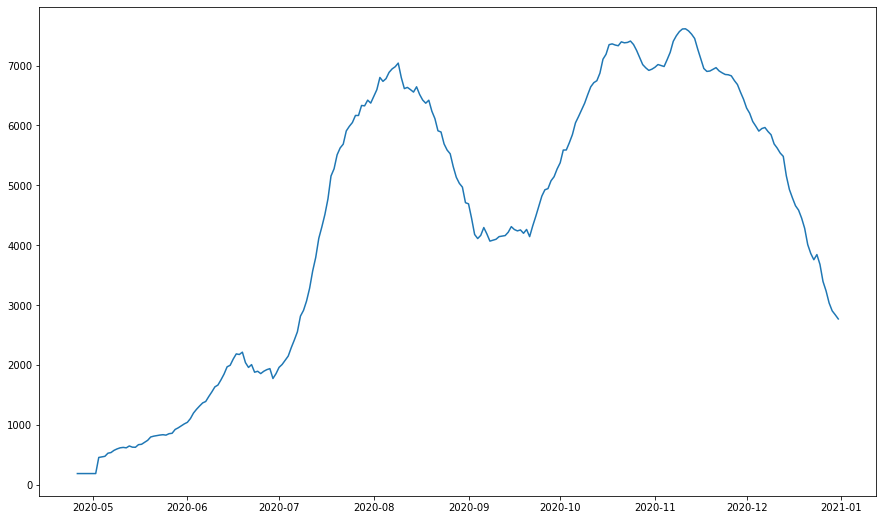

In [70]:
district = 'Kolkata'
bang_data = district_data[district][district_data[district]['Active'] != 'DNA']
bang_data = bang_data[["Active"]]
bang_data = bang_data.astype(int)
print("Trend of Active cases in",district,"for the year 2020")
plt.plot(bang_data)

Trend of Active cases in Kolkata for the year 2021


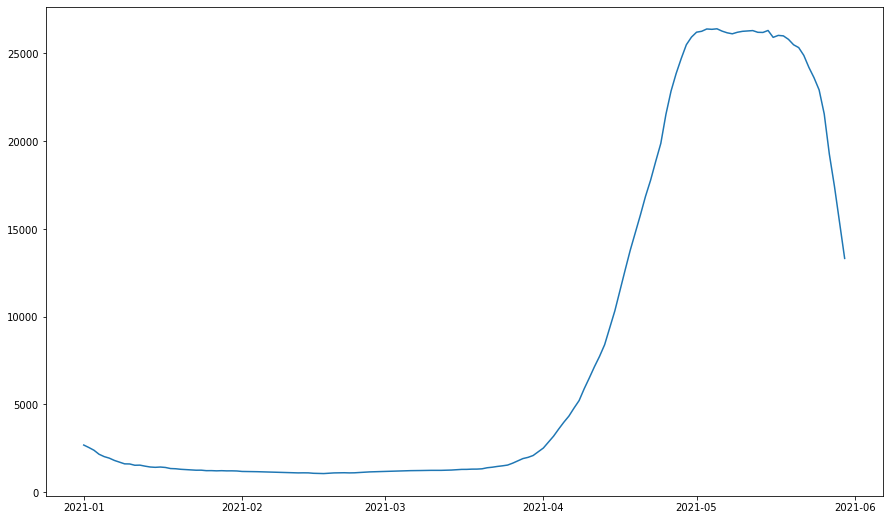

In [71]:
bang_data_21 = district_data_21[district][district_data_21[district]['Active'] != 'DNA']
bang_data_21 = bang_data_21[["Active"]]
bang_data_21 = bang_data_21.astype(int)
print("Trend of Active cases in",district,"for the year 2021")
plt.plot(bang_data_21)

In [72]:
#Quarter-wise div

quart_data = bang_data[bang_data.index >= datetime.date(2020, 1, 1)]
quart1_data = bang_data[quart_data.index < datetime.date(2020, 4, 1)]

quart_data = bang_data[bang_data.index >= datetime.date(2020, 4, 1)]
quart2_data = bang_data[quart_data.index < datetime.date(2020, 7, 1)]

quart_data = bang_data[bang_data.index >= datetime.date(2020, 7, 1)]
quart3_data = quart_data[quart_data.index < datetime.date(2020, 10, 1)]

quart4_data = bang_data[bang_data.index >= datetime.date(2020, 10, 1)]

COVID-19 cases in Kolkata
            Active
Date              
2020-04-26     184
2020-04-27     184
2020-04-28     184
2020-04-29     184
2020-04-30     184
...            ...
2020-12-27    3236
2020-12-28    3034
2020-12-29    2903
2020-12-30    2837
2020-12-31    2767

[250 rows x 1 columns]
            Active
Date              
2021-01-01    2690
2021-01-02    2549
2021-01-03    2394
2021-01-04    2165
2021-01-05    2031
...            ...
2021-05-26   21550
2021-05-27   19263
2021-05-28   17432
2021-05-29   15374
2021-05-30   13322

[150 rows x 1 columns]


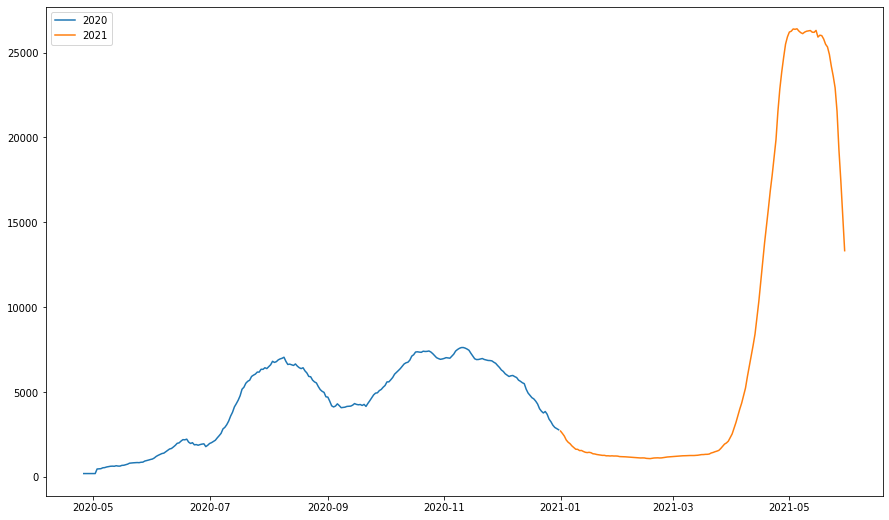

In [73]:
print("COVID-19 cases in",district)
print(bang_data)
print(bang_data_21)
plt.plot(bang_data)
plt.plot(bang_data_21)
plt.legend(['2020','2021'])

# Stationarity check and Transformations

In [74]:
from statsmodels.tsa.stattools import adfuller

(-1.8502523883052429, 0.3558133180199014, 8, 241, {'1%': -3.4577787098622674, '5%': -2.873608704758507, '10%': -2.573201765981991}, 2721.0122764180473)
Non stationary


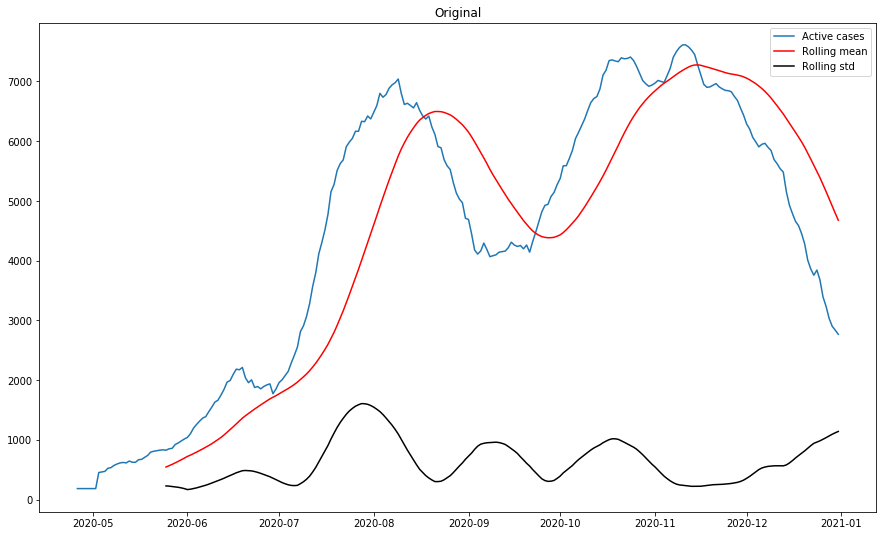

In [75]:
rolmean = bang_data.rolling(window=30).mean()
rolstd = bang_data.rolling(window=30).std()
org = plt.plot(bang_data, label = 'Active cases')
mean = plt.plot(rolmean.dropna(), color = 'Red', label = 'Rolling mean')
std = plt.plot(rolstd.dropna(), color = 'Black', label = 'Rolling std')
plt.legend()
plt.title('Original')

adftst = adfuller(bang_data['Active'], autolag = 'AIC')
print(adftst)

if(adftst[1] < 0.05):
    print('Stationary')
else:
    print('Non stationary')

In [76]:
# Sqrt to fix non-stationarity
bang_data_sqrt = np.sqrt(bang_data)

# Differencing method
bang_data_second = bang_data_sqrt.diff(1)
bang_data_second = bang_data_second.dropna()

(-2.4605568593208873, 0.12536852192915465, 5, 243, {'1%': -3.4575505077947746, '5%': -2.8735087323013526, '10%': -2.573148434859185}, 457.73375984762316)
Non stationary


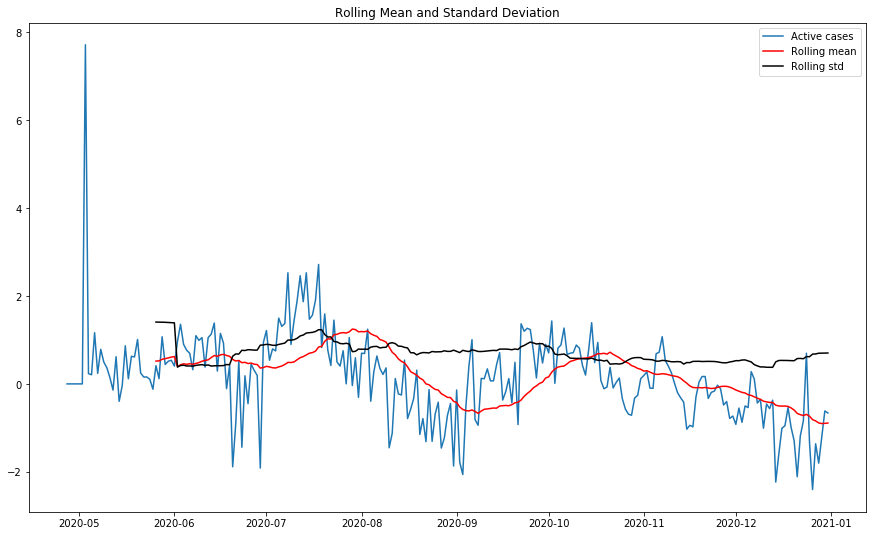

In [77]:
rolmean = bang_data_second.rolling(window=30).mean()
rolstd = bang_data_second.rolling(window=30).std()
org = plt.plot(bang_data_second, label = 'Active cases')
mean = plt.plot(rolmean.dropna(), color = 'Red', label = 'Rolling mean')
std = plt.plot(rolstd.dropna(), color = 'Black', label = 'Rolling std')
plt.legend()
plt.title('Rolling Mean and Standard Deviation')


adftst = adfuller(bang_data_second['Active'].dropna(), autolag = 'AIC')
print(adftst)

if(adftst[1] < 0.05):
    print('Stationary')
else:
    print('Non stationary')

# Parameters for ARIMA

In [78]:
from pmdarima import auto_arima
step_fit = auto_arima(bang_data_second['Active'].dropna(), trace = True)
step_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=612.466, Time=0.24 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=714.054, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=653.644, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=606.580, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=712.056, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=608.562, Time=0.10 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=608.561, Time=0.26 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=610.551, Time=0.12 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=604.794, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=606.782, Time=0.04 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=606.782, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=651.648, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=608.715, Time=0.11 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0]          
Total fit time: 1.039 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  249
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -300.397
Date:                Fri, 04 Jun 2021   AIC                            604.794
Time:                        08:44:45   BIC                            611.821
Sample:                             0   HQIC                           607.623
                                - 249                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7507      0.039    -19.021      0.000      -0.828      -0.673
sigma2         0.6579      0.015     42.772      0.000       0.628       0.688
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             10440.04
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               0.25   Skew:                             3.22
Prob(H) (two-sided):                  0.00   Kurtosis:                        34.13
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

ACF and PACF plots


Text(0.5, 1.0, 'Partial Autocorrelation function')

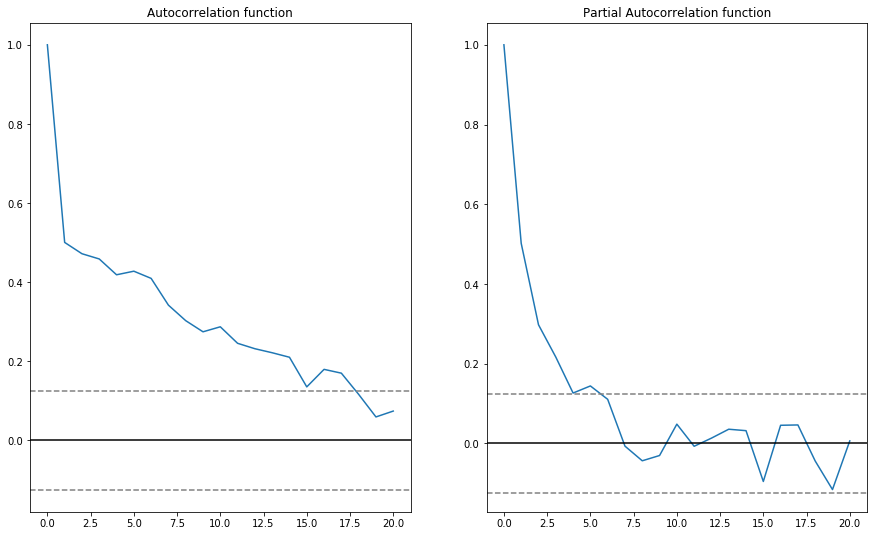

In [79]:
#ACF and PACF
from statsmodels.tsa.stattools import acf,pacf

lag_acf = acf(bang_data_second['Active'].dropna(), nlags = 20)
lag_pacf = pacf(bang_data_second['Active'].dropna(), nlags = 20, method = 'ols')
print("ACF and PACF plots")

# ACF
plt.subplot(121)
plt.plot(lag_acf)
plt.axhline(y = 0, linestyle = '-', color = 'black')
plt.axhline(y=-1.96/np.sqrt(len(bang_data_second)),linestyle='--',color = 'gray')
plt.axhline(y=1.96/np.sqrt(len(bang_data_second)),linestyle='--',color = 'gray')
plt.title('Autocorrelation function')

# ACF
plt.subplot(122)
plt.plot(lag_pacf)
plt.axhline(y = 0, linestyle = '-', color = 'black')
plt.axhline(y=-1.96/np.sqrt(len(bang_data_second)),linestyle='--',color = 'gray')
plt.axhline(y=1.96/np.sqrt(len(bang_data_second)),linestyle='--',color = 'gray')
plt.title('Partial Autocorrelation function')

ACF and PACF corellograms


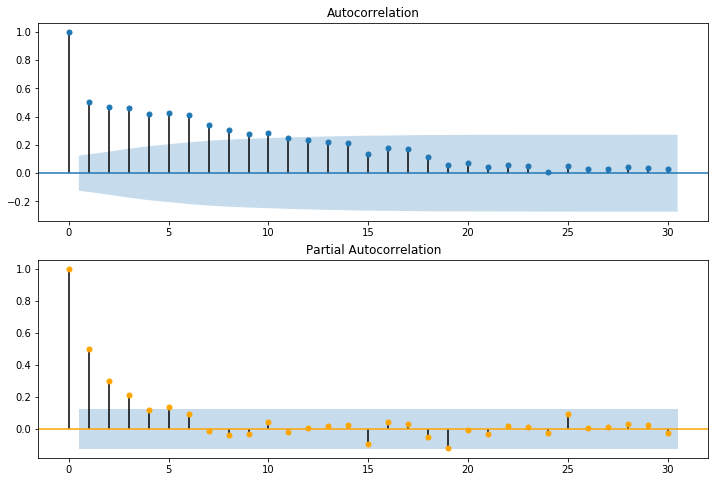

In [80]:
import statsmodels.api as sm

print("ACF and PACF corellograms")
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(bang_data_second['Active'].dropna(),lags = 30, ax = ax1)

ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(bang_data_second['Active'].dropna(),lags = 30, color='orange', ax = ax2)

# ARIMA model forecasts 

AR model
MSE :  1.021161749002573


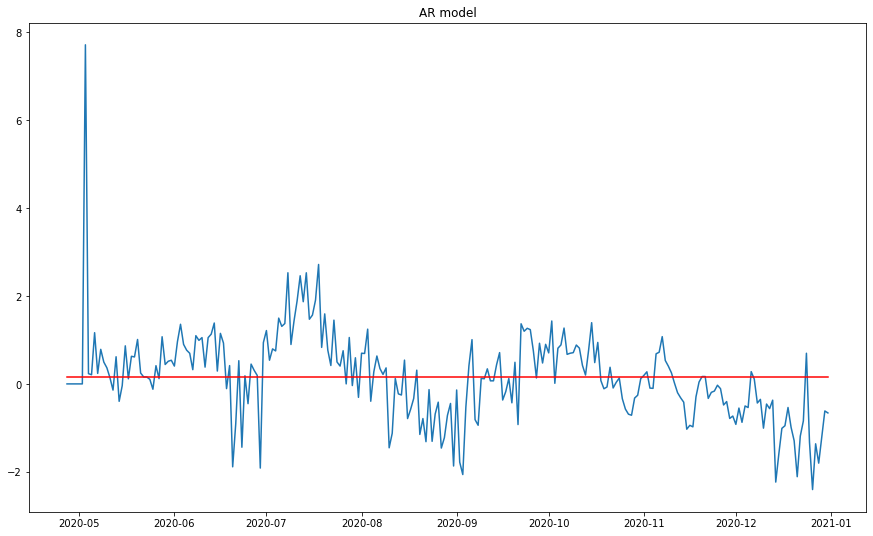

In [81]:
from statsmodels.tsa.arima_model import ARIMA

print("AR model")
model = ARIMA(bang_data_sqrt,order = (0,1,0))
res_AR = model.fit(disp=-1)
plt.plot(bang_data_second)
plt.plot(res_AR.fittedvalues, color = 'red')
plt.title('AR model')
mse = 1/len(bang_data_sqrt)*sum((res_AR.fittedvalues-bang_data_second['Active'].dropna())**2)
print('MSE : ',mse)

MA model
0.8553038878194676


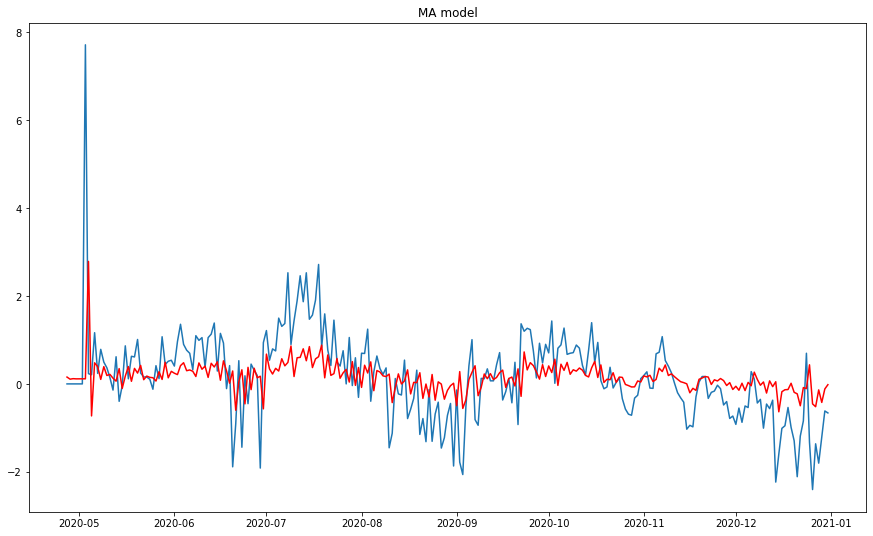

In [82]:
print("MA model")
model = ARIMA(bang_data_sqrt,order = (0,1,1))
res_MA = model.fit(disp=-1)
plt.plot(bang_data_second)
plt.plot(res_MA.fittedvalues, color = 'red')
plt.title('MA model')
mse = 1/len(bang_data_sqrt)*sum((res_MA.fittedvalues-bang_data_second['Active'].dropna())**2)
print(mse)

ARIMA model
0.6421188954594221


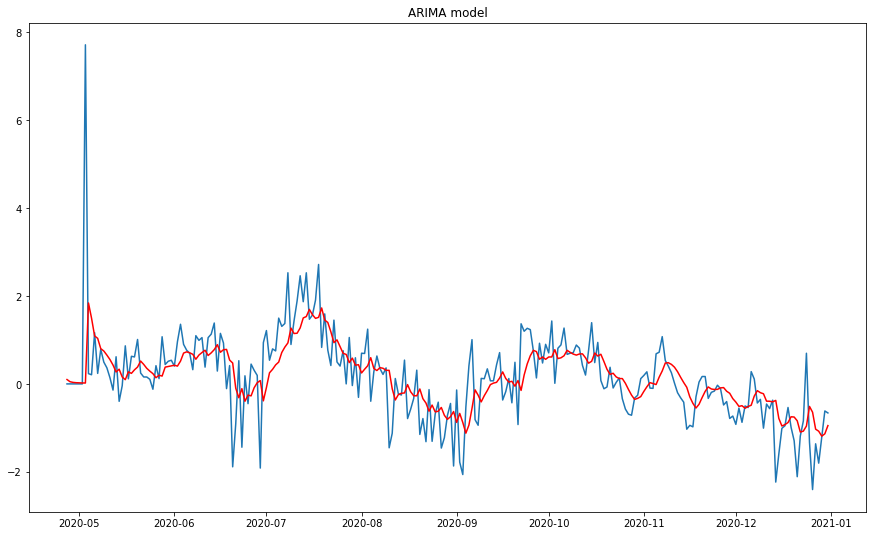

In [91]:
print("ARIMA model")
model = ARIMA(bang_data_sqrt,order = (2,1,1))
res_ARIMA = model.fit(disp=-1)
plt.plot(bang_data_second)
plt.plot(res_ARIMA.fittedvalues, color = 'red')
plt.title('ARIMA model')
mse = 1/len(bang_data_sqrt)*sum((res_ARIMA.fittedvalues-bang_data_second['Active'].dropna())**2)
print(mse)

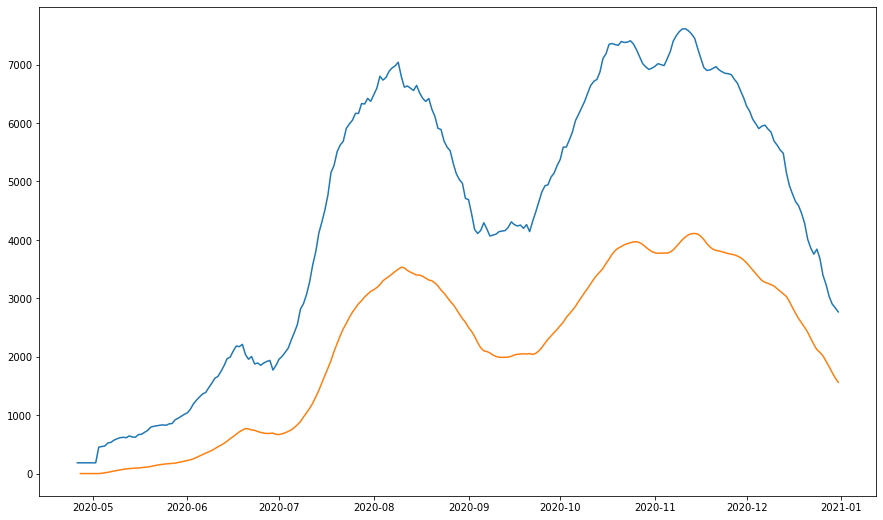

In [92]:
pred_arima = pd.Series(res_ARIMA.fittedvalues, copy=True)
pred_arima = pred_arima.cumsum()
pred_fin = (pred_arima**2)
plt.plot(bang_data)
plt.plot(pred_fin)

In [93]:
def get_err(ress):
    lst = bang_data_21.values
    sm = 0
    l = min(len(bang_data_21),len(ress))
    for i in range(l):
        x = ((lst[i]-ress[i])/lst[i])**2
        sm = sm + x
    rmse = 100 - (math.sqrt(sm/l))*100
    return rmse

In [94]:
rmse_for_tab = []
for i in range(1,15):
    period = int(i)
    r = res_ARIMA.forecast(steps=period)
    ress = r[0]**2
    rmse = get_err(ress)
    rmse_for_tab.append(rmse)

In [95]:
eval_matrix = pd.DataFrame(columns=['Time frame','Date','All data'])

In [96]:
tim = []

print("Confidence Interval of forecast over 1st test interval")
for i in range(len(rmse_for_tab)):
    tim.append((i+1))
eval_matrix['Time frame'] = tim
eval_matrix['Date'] = bang_data_21.index[:14]
eval_matrix['All data'] = rmse_for_tab
eval_matrix.set_index('Time frame',inplace=True)
eval_matrix

Confidence Interval of forecast over 1st test interval


,Date,All data
Time frame,,
1,2021-01-01,99.687057
2,2021-01-02,98.488595
3,2021-01-03,96.496565
4,2021-01-04,92.492423
5,2021-01-05,89.464894
6,2021-01-06,87.264736
7,2021-01-07,84.607539
8,2021-01-08,82.048632
9,2021-01-09,79.361490


Forecast of trend of growth of COVID-19 for the 1st test interval
               Forecast  Daily forecast  Confidence interval  Actual  Daily
Date                                                                       
2021-01-01  2681.581823             -86            99.687057    2690    -77
2021-01-02  2602.896488             -79            98.488595    2549   -141
2021-01-03  2529.960415             -73            96.496565    2394   -155
2021-01-04  2462.348917             -67            92.492423    2165   -229
2021-01-05  2399.662854             -63            89.464894    2031   -134
2021-01-06  2341.537025             -58            87.264736    1944    -87
2021-01-07  2287.636805             -54            84.607539    1813   -131
2021-01-08  2237.655357             -50            82.048632    1717    -96
2021-01-09  2191.311105             -46            79.361490    1618    -99
2021-01-10  2148.345450             -43            77.772624    1612     -6
2021-01-11  2108.52070

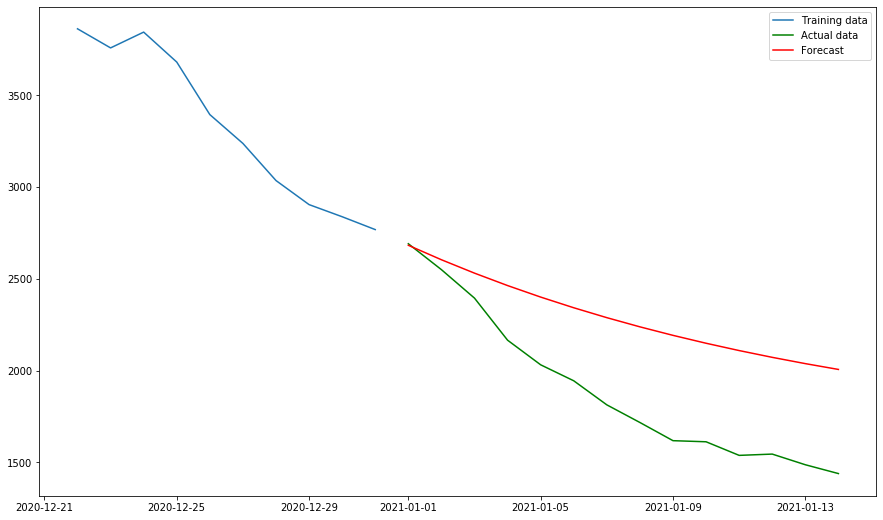

In [97]:
dt = bang_data.index[-1]
end = dt + datetime.timedelta(days=len(ress)+1)
step = datetime.timedelta(days=1)
dtframe = []
while dt < end:
    dte = (dt.strftime('%Y-%m-%d'))
    dtframe.append((datetime.datetime.strptime(dte, '%Y-%m-%d')).date())
    dt += step
    
print("Forecast of trend of growth of COVID-19 for the 1st test interval")
daily = []
tst = pd.DataFrame()
tst['Date'] = dtframe[1:]
tst['Forecast'] = ress
daily.append(int(ress[0])-int(bang_data[-1:].values))
for i in range(1,len(ress)):
    daily.append(int(ress[i])-int(ress[i-1]))
tst['Daily forecast'] = daily
tst['Confidence interval'] = rmse_for_tab
tst['Actual'] = bang_data_21.values[:len(ress)]
cum = bang_data_21.values
daily = []
daily.append(int(cum[0])-int(bang_data[-1:].values))
for i in range(1,len(ress)):
    daily.append(int(cum[i])-int(cum[i-1]))
tst['Daily'] = daily
tst.set_index('Date',inplace=True)

print(tst)
plt.plot(bang_data[-10:])
plt.plot(bang_data_21[:len(ress)],color='green')
plt.plot(tst['Forecast'],color='red')
plt.legend(['Training data','Actual data','Forecast'])

# Forecasts over 2nd test interval

(-4.996718364718416, 2.2527447892080794e-05, 16, 383, {'1%': -3.44753973676872, '5%': -2.8691160516676844, '10%': -2.57080585953957}, 4726.162002474222)
Stationary


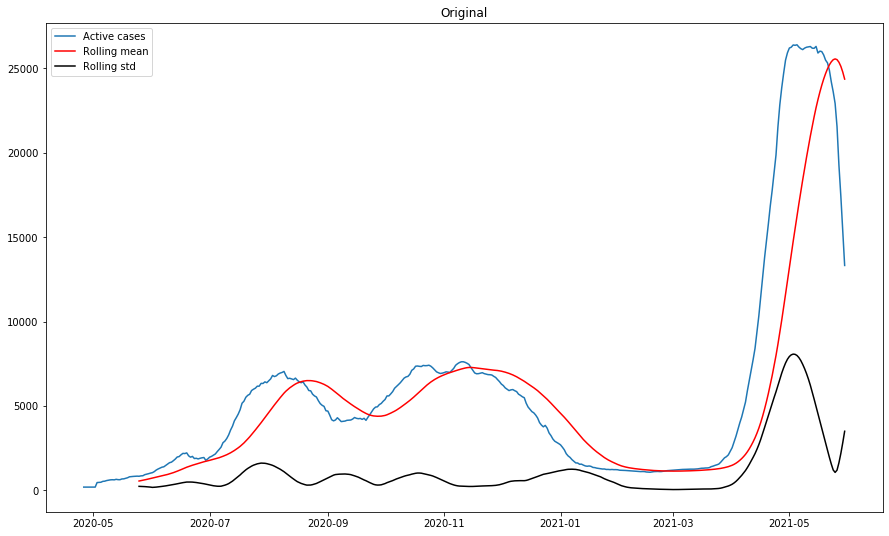

In [98]:
all_data = pd.concat([bang_data,bang_data_21])
rolmean = all_data.rolling(window=30).mean()
rolstd = all_data.rolling(window=30).std()
org = plt.plot(all_data, label = 'Active cases')
mean = plt.plot(rolmean.dropna(), color = 'Red', label = 'Rolling mean')
std = plt.plot(rolstd.dropna(), color = 'Black', label = 'Rolling std')
plt.legend()
plt.title('Original')

adftst = adfuller(all_data['Active'], autolag = 'AIC')
print(adftst)

if(adftst[1] < 0.05):
    print('Stationary')
else:
    print('Non stationary')

(-4.242723981177119, 0.0005573660597781645, 4, 394, {'1%': -3.4470566389664703, '5%': -2.8689037160476016, '10%': -2.570692663557422}, 764.067660508337)
Stationary


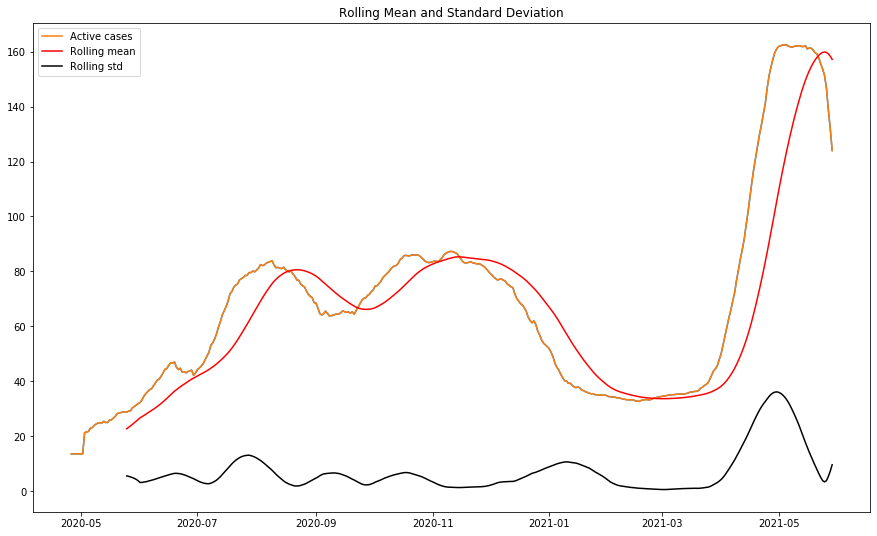

In [99]:
# Sqrt to fix non-stationarity
bang_data_sqrt = np.sqrt(all_data[:-1])
plt.plot(bang_data_sqrt)

rolmean = bang_data_sqrt.rolling(window=30).mean()
rolstd = bang_data_sqrt.rolling(window=30).std()
org = plt.plot(bang_data_sqrt, label = 'Active cases')
mean = plt.plot(rolmean.dropna(), color = 'Red', label = 'Rolling mean')
std = plt.plot(rolstd.dropna(), color = 'Black', label = 'Rolling std')
plt.legend()
plt.title('Rolling Mean and Standard Deviation')


adftst = adfuller(bang_data_sqrt['Active'], autolag = 'AIC')
print(adftst)

if(adftst[1] < 0.05):
    print('Stationary')
else:
    print('Non stationary')

(-0.9755384055822328, 0.7620812364023037, 7, 390, {'1%': -3.4472291365835566, '5%': -2.8689795375849223, '10%': -2.5707330834976987}, 779.554997752983)
Non stationary


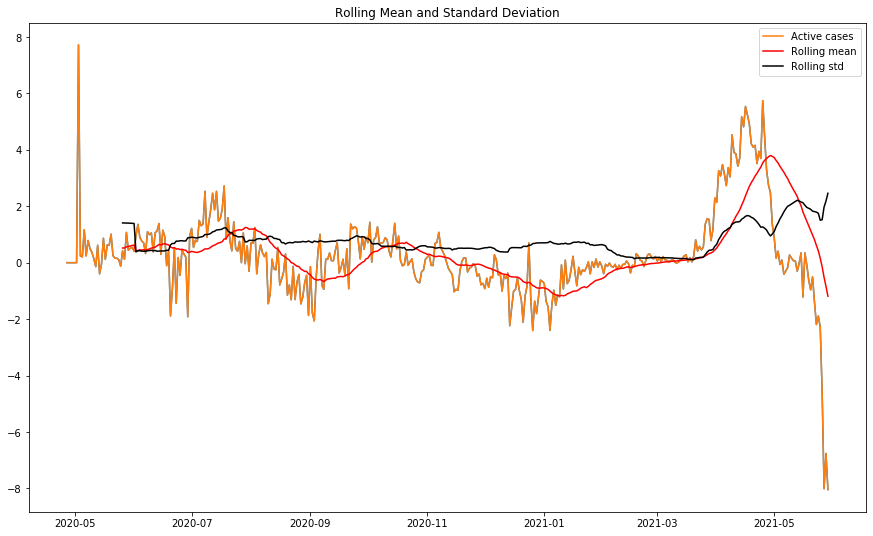

In [100]:
# Differencing method
bang_data_second = bang_data_sqrt.diff(1)
bang_data_second = bang_data_second.dropna()
plt.plot(bang_data_second)

rolmean = bang_data_second.rolling(window=30).mean()
rolstd = bang_data_second.rolling(window=30).std()
org = plt.plot(bang_data_second, label = 'Active cases')
mean = plt.plot(rolmean.dropna(), color = 'Red', label = 'Rolling mean')
std = plt.plot(rolstd.dropna(), color = 'Black', label = 'Rolling std')
plt.legend()
plt.title('Rolling Mean and Standard Deviation')


adftst = adfuller(bang_data_second['Active'].dropna(), autolag = 'AIC')
print(adftst)

if(adftst[1] < 0.05):
    print('Stationary')
else:
    print('Non stationary')

In [101]:
step_fit = auto_arima(bang_data_second['Active'].dropna(), trace = True)
step_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=947.710, Time=0.47 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=1475.861, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=1021.072, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=1266.140, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1486.616, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=958.680, Time=0.21 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=958.762, Time=0.24 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=954.300, Time=0.52 sec
 ARIMA(2,0,3)(0,0,0)[0] intercept   : AIC=951.424, Time=0.51 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=957.421, Time=0.14 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=960.228, Time=0.27 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=960.531, Time=0.21 sec
 ARIMA(3,0,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.63 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.28 sec

Best model:  ARIMA(2,0,2)(0,0,0)[0] intercept
Tota

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  398
Model:               SARIMAX(2, 0, 2)   Log Likelihood                -467.855
Date:                Fri, 04 Jun 2021   AIC                            947.710
Time:                        08:46:01   BIC                            971.629
Sample:                             0   HQIC                           957.184
                                - 398                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   7.405e-05      0.001      0.120      0.905      -0.001       0.001
ar.L1          1.9916      0.004    483.850      0.000       1.984       2.000
ar.L2         -0.9942      0.003   -296.369      0.000      -1.001      -0.988
ma.L1         -1.5378      0.030    -50.912      0.000      -1.597      -1.479
ma.L2          0.5452      0.029     18.795      0.000       0.488       0.602
sigma2         0.6071      0.019     31.343      0.000       0.569       0.645
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              8639.81
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):               0.47   Skew:                             1.19
Prob(H) (two-sided):                  0.00   Kurtosis:                        25.70
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

0.6574467251639201


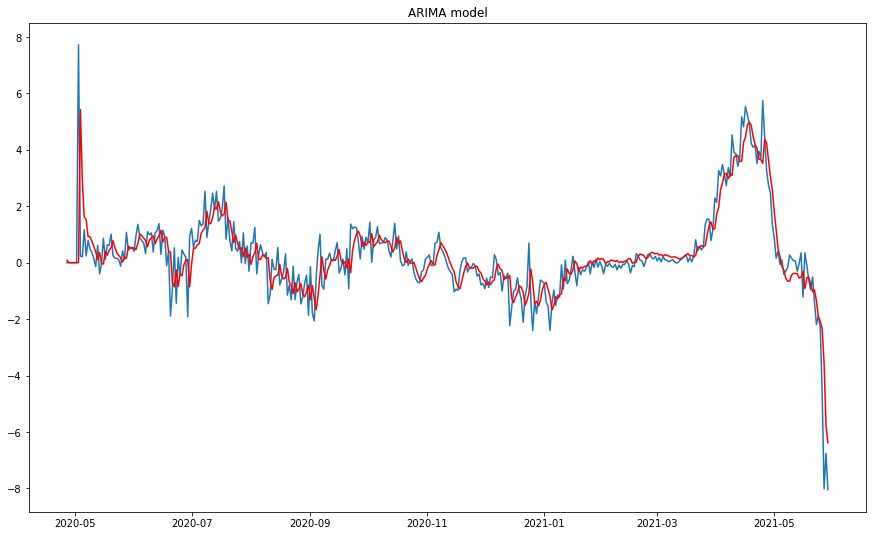

In [105]:
model = ARIMA(bang_data_sqrt,order = (2,1,2))
res_ARIMA = model.fit(disp=-1)
plt.plot(bang_data_second)
plt.plot(res_ARIMA.fittedvalues, color = 'red')
plt.title('ARIMA model')
mse = 1/len(bang_data_sqrt)*sum((res_ARIMA.fittedvalues-bang_data_second['Active'].dropna())**2)
print(mse)

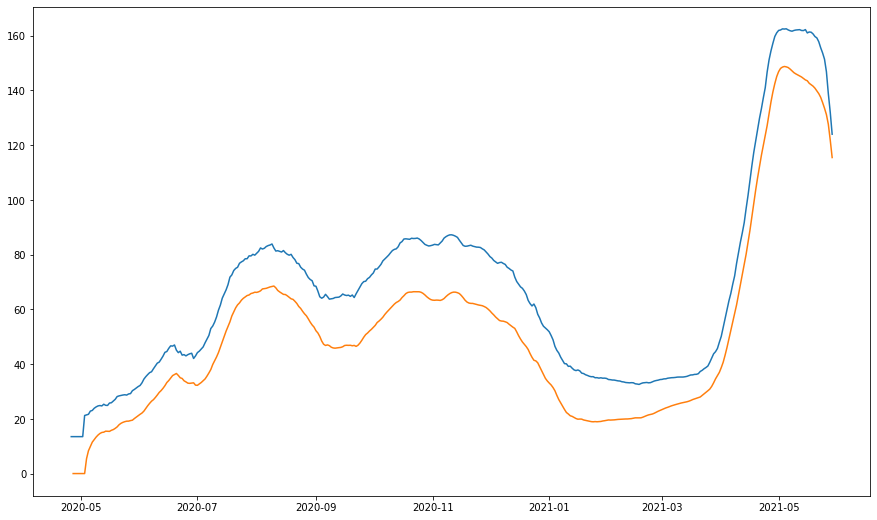

In [106]:
pred_arima = pd.Series(res_ARIMA.fittedvalues, copy=True)
pred_arima = pred_arima.cumsum()
plt.plot(bang_data_sqrt)
plt.plot(pred_arima)

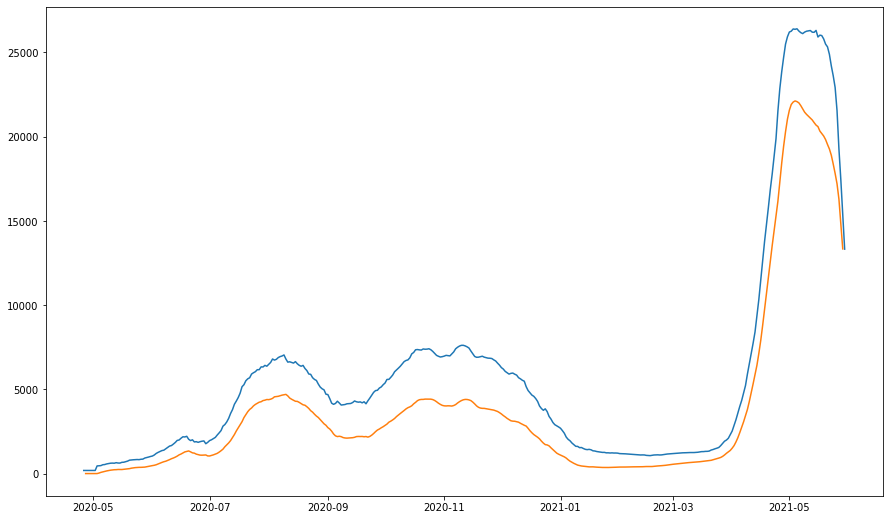

In [107]:
pred_fin = (pred_arima**2)
plt.plot(all_data)
plt.plot(pred_fin)

In [108]:
r = res_ARIMA.forecast(steps=14)
ress = r[0]**2
print(ress)

[13617.88532187 11937.57591264 10343.14166379  8843.67441325
  7447.21425247  6160.68662598  4989.85080793  3939.26022597
  3012.23498406  2210.8468137   1535.91655856   987.02417239
   562.53108511   259.61466847]


            Daily        Active  Confidence Interval
Date                                                
2021-05-30    295  13617.885322            99.687057
2021-05-31  -1680  11937.575913            98.488595
2021-06-01  -1594  10343.141664            96.496565
2021-06-02  -1500   8843.674413            92.492423
2021-06-03  -1396   7447.214252            89.464894
2021-06-04  -1287   6160.686626            87.264736
2021-06-05  -1171   4989.850808            84.607539
2021-06-06  -1050   3939.260226            82.048632


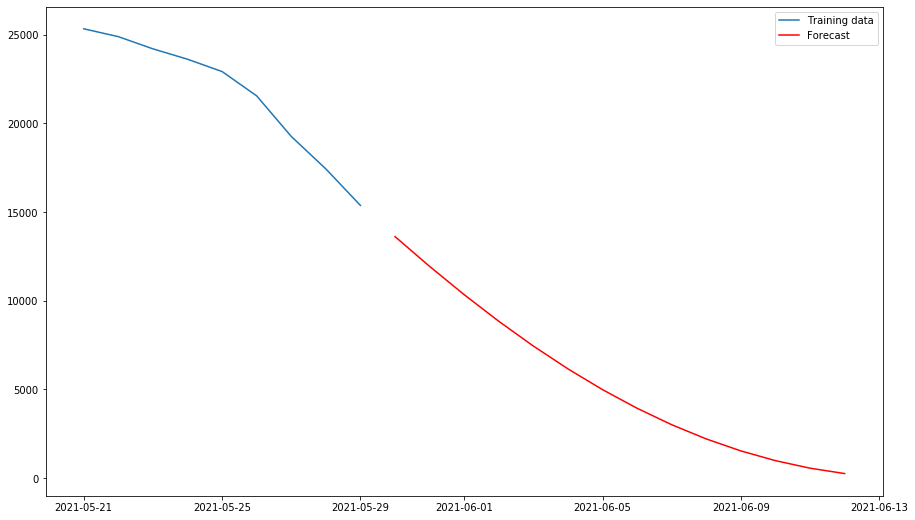

In [109]:
dt = all_data.index[-1]
end = dt + datetime.timedelta(days=len(ress))
step = datetime.timedelta(days=1)
dtframe = []
while dt < end:
    dte = (dt.strftime('%Y-%m-%d'))
    dtframe.append((datetime.datetime.strptime(dte, '%Y-%m-%d')).date())
    dt += step
    
tst = pd.DataFrame()
tst['Date'] = dtframe
daily = []
daily.append(int(ress[0])-int(all_data[-1:].values))
for i in range(1,len(ress)):
    daily.append(int(ress[i])-int(ress[i-1]))
tst['Daily'] = daily
tst['Active'] = ress
tst['Confidence Interval'] = rmse_for_tab[:len(ress)]
tst.set_index('Date',inplace=True)
print(tst[:8])
plt.plot(all_data[-10:-1])
plt.plot(tst['Active'],color='red')
plt.legend(['Training data','Forecast'])